<h1><b>Rail Corrugation Data Preprocessing</b></h1>

<h4><b>Background Information</b></h4>

The Rail corrugation subsystem in NEBULA X Problem Statement 3 uses one-second axle-box recordings
from an eight-car train. Each recording is labelled `Normal`, `Side I` (corrugation on the rail under
the odd axle-box positions) or `Side II` (the even positions), and predictions are scored by macro F1
over the three classes. The Rail corrugation exploratory data analysis found two duplicated recordings,
strong class imbalance, and a confound between class and train speed.

<h4><b>Objective</b></h4>

This notebook converts the 340 raw recordings into validated, model-ready tables. It audits every
file, derives train speed from the tachometer pulse, checks channel health, conditions the signals,
extracts per-channel time-domain, spectral and wavelength-band features, aggregates them per side and
as same-axle side contrasts, compares Train and Test coverage, assigns grouped stratified folds, and
saves the results with the spectra. No model is trained and no Test label is inferred.

<h4><b>Project Workflow</b></h4>

The workflow configures the environment, inventories the files and labels, and checks header
consistency and the channel layout. A first pass audits dimensions, types, missing and invalid values,
duplicates, channel health and speed; a second pass extracts features after offset removal. The
features are aggregated, compared between Train and Test, assigned to folds, and exported.

<h4><b>Dataset Used</b></h4>

`PS3/02_Datasets/Rail_Corrugation` contains 272 labelled Train recordings, 68 unlabelled Test
recordings and `Train_Labels.csv`. Each CSV holds 10,000 rows sampled at 10 kHz: a `Rotating speed`
pulse from a 90-tooth wheel, then vibration and shock channels for axle-box positions 1 to 8 of cars 1
to 8. The speed conversion assumes a wheel diameter of 0.85 m, as in the exploratory analysis. Outputs
are written to `data/processed/rail`, which is excluded from version control.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup and Configuration</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Display Settings</a></li>
      <li><a href="#1-2">1.2 Dataset Location and Output Directory</a></li>
      <li><a href="#1-3">1.3 Environment Versions</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Data Loading and Inventory</a>
    <ul>
      <li><a href="#2-1">2.1 File Inventory</a></li>
      <li><a href="#2-2">2.2 Label Loading and Coverage</a></li>
      <li><a href="#2-3">2.3 Header Consistency</a></li>
      <li><a href="#2-4">2.4 Channel Map</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Data Inspection and Validation</a>
    <ul>
      <li><a href="#3-1">3.1 Per-File Quality Audit</a></li>
      <li><a href="#3-2">3.2 Dimensions, Types and Invalid Values</a></li>
      <li><a href="#3-3">3.3 Duplicate Recordings</a></li>
      <li><a href="#3-4">3.4 Channel Health</a></li>
      <li><a href="#3-5">3.5 Speed Derivation and Distribution</a></li>
      <li><a href="#3-6">3.6 Speed Distribution Plots</a></li>
      <li><a href="#3-7">3.7 Class Counts by Speed Band</a></li>
      <li><a href="#3-8">3.8 Sample Traces</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Signal Conditioning and Band Definitions</a>
    <ul>
      <li><a href="#4-1">4.1 Offset Removal</a></li>
      <li><a href="#4-2">4.2 Spectral Estimation Settings</a></li>
      <li><a href="#4-3">4.3 Frequency and Wavelength Bands</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Feature Extraction</a>
    <ul>
      <li><a href="#5-1">5.1 Channel Feature Function</a></li>
      <li><a href="#5-2">5.2 Extraction Pass</a></li>
      <li><a href="#5-3">5.3 Side Aggregation</a></li>
      <li><a href="#5-4">5.4 Same-Axle Side Contrasts</a></li>
      <li><a href="#5-5">5.5 File-Level Feature Table</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Train and Test Comparability</a>
    <ul>
      <li><a href="#6-1">6.1 Feature Range Comparison</a></li>
      <li><a href="#6-2">6.2 Wavelength Coverage by Speed</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Validation Folds</a>
    <ul>
      <li><a href="#7-1">7.1 Grouped Stratified Folds</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Export</a>
    <ul>
      <li><a href="#8-1">8.1 Output Tables</a></li>
      <li><a href="#8-2">8.2 Manifest</a></li>
      <li><a href="#8-3">8.3 Export Verification</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Conclusions</a>
    <ul>
      <li><a href="#9-1">9.1 Prepared Outputs</a></li>
      <li><a href="#9-2">9.2 Data Quality Findings</a></li>
      <li><a href="#9-3">9.3 Implications for Modelling</a></li>
    </ul>
  </li>
</ul>

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup and Configuration</b></h2>
</div>

This section imports the required libraries, fixes the acquisition constants, display settings and
random seed, and locates the dataset and the output directory.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Display Settings</b></h3></blockquote>

In the cell below, the numerical, signal-processing and model-selection libraries are imported. Shared
constants define the sampling rate, the tachometer geometry, the random seed, the class names and the
plot colours.

In [1]:
from pathlib import Path
import os
import re
import json
import hashlib
import platform
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, stats
from sklearn.model_selection import StratifiedGroupKFold
from IPython.display import display

FS = 10_000              # samples per second
TEETH = 90               # teeth on the speed-sensor wheel
WHEEL_DIAMETER_M = 0.85  # wheel diameter for converting revolutions to distance
SEED = 2026
CLASSES = ['Normal', 'Side I', 'Side II']
COLORS = {'Normal': '#16857b', 'Side I': '#d95f38', 'Side II': '#2878a5', 'Test': '#8256b3'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 80)
pd.set_option('display.width', 170)

<blockquote><h3 id="1-2"><b>1.2 Dataset Location and Output Directory</b></h3></blockquote>

The Rail corrugation folder is found from the working directory, or from `TFD_PS3_DIR` when that
variable names the PS3 folder or its `02_Datasets` folder. Outputs go to `data/processed/rail` under
the repository root unless `TFD_PROCESSED_DIR` overrides the parent folder. Paths are displayed
relative to the repository so that saved outputs carry no machine-specific prefix.

In [2]:
def find_repo_root():
    """Nearest ancestor of the working directory that holds `pyproject.toml`."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'pyproject.toml').is_file():
            return base
    return Path.cwd()


def find_dataset(subsystem):
    """Locate a PS3 subsystem folder.

    `TFD_PS3_DIR` may name the PS3 folder or its `02_Datasets` folder. Otherwise the working directory
    and its parents are searched for `problem-statement/PS3/02_Datasets`, `PS3/02_Datasets` and
    `02_Datasets`.
    """
    if os.environ.get('TFD_PS3_DIR'):
        root = Path(os.environ['TFD_PS3_DIR']).expanduser()
        candidates = [root / subsystem, root / '02_Datasets' / subsystem]
    else:
        suffixes = ['problem-statement/PS3/02_Datasets', 'PS3/02_Datasets', '02_Datasets']
        candidates = [base / suffix / subsystem for base in [Path.cwd(), *Path.cwd().parents] for suffix in suffixes]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(f'{subsystem} not found; set TFD_PS3_DIR to the PS3 or 02_Datasets folder.')


def shown(path):
    """Path relative to the repository root, or only its name when it lies outside the repository."""
    try:
        return Path(path).resolve().relative_to(REPO_ROOT).as_posix()
    except ValueError:
        return Path(path).name


REPO_ROOT = find_repo_root()
RAIL_DIR = find_dataset('Rail_Corrugation')
OUT_DIR = Path(os.environ.get('TFD_PROCESSED_DIR', REPO_ROOT / 'data' / 'processed')) / 'rail'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Dataset:', shown(RAIL_DIR))
print('Output: ', shown(OUT_DIR))

Dataset: problem-statement/PS3/02_Datasets/Rail_Corrugation
Output:  data/processed/rail


<blockquote><h3 id="1-3"><b>1.3 Environment Versions</b></h3></blockquote>

In the cell below, the Python and package versions are recorded so that the saved results can be
reproduced.

In [3]:
versions = {'Python': platform.python_version(), **{name: importlib.metadata.version(name) for name in ['numpy', 'pandas', 'scipy', 'scikit-learn', 'pyarrow', 'matplotlib']}}
display(pd.Series(versions, name='version').to_frame())

,version
Python,3.12.14
numpy,2.4.6
pandas,2.3.3
scipy,1.18.1
scikit-learn,1.9.1
pyarrow,25.0.0
matplotlib,3.11.2


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Data Loading and Inventory</b></h2>
</div>

This section lists the recordings, validates the label file against them, confirms that every file
shares one header, and builds the channel map that identifies each column's kind, car, position and
rail side.

<blockquote><h3 id="2-1"><b>2.1 File Inventory</b></h3></blockquote>

In the cell below, the Train and Test recordings are listed in numeric order with their sizes. File
names are checked against the `TrainN.csv` and `TestN.csv` patterns, and the numbering is checked to
run without gaps from 1.

In [4]:
def file_number(path):
    """Numeric part of a `TrainN.csv` or `TestN.csv` file name."""
    return int(re.fullmatch(r'(?:Train|Test)(\d+)\.csv', path.name).group(1))


paths = {split: sorted((RAIL_DIR / split).glob('*.csv'), key=file_number) for split in ['Train', 'Test']}
files = pd.DataFrame([{'dataset': split, 'filename': p.name, 'number': file_number(p), 'size_MB': p.stat().st_size / 1e6}
                      for split, split_paths in paths.items() for p in split_paths])
inventory = files.groupby('dataset', sort=False).agg(files=('filename', 'size'), first=('number', 'min'),
                                                     last=('number', 'max'), total_GB=('size_MB', 'sum'),
                                                     median_MB=('size_MB', 'median'))
inventory['total_GB'] = (inventory['total_GB'] / 1e3).round(2)
inventory['numbering without gaps'] = [set(files.loc[files['dataset'].eq(d), 'number']) == set(range(1, n + 1))
                                       for d, n in inventory['files'].items()]
display(inventory.round(2))

,files,first,last,total_GB,median_MB,numbering without gaps
dataset,,,,,,
Train,272,1,272,4.71,17.28,True
Test,68,1,68,1.18,17.28,True


<blockquote><h3 id="2-2"><b>2.2 Label Loading and Coverage</b></h3></blockquote>

In the cell below, the labels are checked for missing cells, duplicate file names, unknown classes and
agreement with the Train files, and the class counts and shares are displayed.

In [5]:
label_table = pd.read_csv(RAIL_DIR / 'Train_Labels.csv', dtype=str)
train_names = set(files.loc[files['dataset'].eq('Train'), 'filename'])
display(pd.Series({
    'label rows': len(label_table),
    'missing cells': int(label_table.isna().sum().sum()),
    'duplicate file names': int(label_table['filename'].duplicated().sum()),
    'unknown classes': len(set(label_table['label']) - set(CLASSES)),
    'labels without a file': len(set(label_table['filename']) - train_names),
    'Train files without a label': len(train_names - set(label_table['filename'])),
}, name='count').to_frame())
labels = label_table.set_index('filename')['label']
counts = labels.value_counts().reindex(CLASSES).rename('files').to_frame()
counts['share'] = (counts['files'] / counts['files'].sum()).round(3)
display(counts)

,count
label rows,272
missing cells,0
duplicate file names,0
unknown classes,0
labels without a file,0
Train files without a label,0


,files,share
label,,
Normal,234,0.860
Side I,14,0.051
Side II,24,0.088


<blockquote><h3 id="2-3"><b>2.3 Header Consistency</b></h3></blockquote>

In the cell below, the first line of every recording is read and the distinct header lines are counted.
A single header means every file shares the same columns in the same order.

In [6]:
header_lines = {}
for path in paths['Train'] + paths['Test']:
    with open(path) as handle:
        header_lines.setdefault(handle.readline().rstrip('\r\n'), []).append(path.name)
assert len(header_lines) == 1, 'Recordings differ in their header; review before extraction.'
COLUMNS = next(iter(header_lines)).split(',')
print('Distinct header lines:', len(header_lines), '| columns per file:', len(COLUMNS))

Distinct header lines: 1 | columns per file: 129


<blockquote><h3 id="2-4"><b>2.4 Channel Map</b></h3></blockquote>

In the cell below, each acceleration column is parsed into its kind (vibration or shock), car and
axle-box position. Odd positions run on the Side I rail and even positions on the Side II rail.
Positions are paired as (1, 2), (3, 4), (5, 6) and (7, 8) to represent the two ends of one axle; this
pairing is an assumption, because the data does not state the axle layout.

In [7]:
SPEED = 'Rotating speed'
CHANNEL = re.compile(r'^(Vibration|Shock) of bearing in position (\d) of car (\d)$')
channel_rows = []
for column in COLUMNS[1:]:
    kind, position, car = CHANNEL.match(column).groups()
    channel_rows.append({'column': column, 'kind': kind, 'car': int(car), 'position': int(position),
                         'side': 'Side I' if int(position) % 2 else 'Side II', 'axle': (int(position) + 1) // 2})
channels = pd.DataFrame(channel_rows)
assert COLUMNS[0] == SPEED and len(channels) == 128
assert not channels.duplicated(['kind', 'car', 'position']).any()
display(pd.crosstab([channels['kind'], channels['side']], channels['car'], margins=True))
display(channels.head(4))

car                 1   2   3   4   5   6   7   8  All
kind      side                                        
Shock     Side I    4   4   4   4   4   4   4   4   32
          Side II   4   4   4   4   4   4   4   4   32
Vibration Side I    4   4   4   4   4   4   4   4   32
          Side II   4   4   4   4   4   4   4   4   32
All                16  16  16  16  16  16  16  16  128

,column,kind,car,position,side,axle
0,Vibration of bearing in position 1 of car 1,Vibration,1,1,Side I,1
1,Shock of bearing in position 1 of car 1,Shock,1,1,Side I,1
2,Vibration of bearing in position 2 of car 1,Vibration,1,2,Side II,1
3,Shock of bearing in position 2 of car 1,Shock,1,2,Side II,1


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Data Inspection and Validation</b></h2>
</div>

This section audits every recording in a first pass, then summarises dimensions, types, missing and
invalid values, duplicates, channel health, speed, sample traces and class counts by speed.

<blockquote><h3 id="3-1"><b>3.1 Per-File Quality Audit</b></h3></blockquote>

In the cell below, each recording is read with its column order checked. The audit counts non-numeric
columns, missing and infinite values, pulse values other than 0 and 1, and constant channels; derives
speed from the rising edges of the pulse (and from both edges as a cross-check); records the largest
absolute acceleration; and fingerprints the full recording and the acceleration channels alone.
Per-channel mean, standard deviation, range, share of samples at the channel's extremes, number of
distinct levels and quantisation step (the smallest gap between distinct values) are kept for the
channel-health checks.

In [8]:
def read_recording(path):
    """Read one recording and confirm that its columns match the shared header."""
    frame = pd.read_csv(path, engine='pyarrow')
    assert list(frame.columns) == COLUMNS, f'{path.name}: unexpected columns'
    return frame


def audit(path):
    """File-level quality record and per-channel statistics for one recording."""
    frame = read_recording(path)
    values = frame.to_numpy(dtype=float)
    pulse, accel = values[:, 0], values[:, 1:]
    edges = np.diff(pulse)
    rising, falling = int((edges == 1).sum()), int((edges == -1).sum())
    to_kmh = np.pi * WHEEL_DIAMETER_M * 3.6 / TEETH / ((len(pulse) - 1) / FS)  # one tooth per rising edge
    record = {
        'rows': frame.shape[0], 'columns': frame.shape[1],
        'non_numeric_columns': int((~frame.dtypes.map(pd.api.types.is_numeric_dtype)).sum()),
        'missing': int(np.isnan(values).sum()), 'infinite': int(np.isinf(values).sum()),
        'invalid_pulse_values': int((~np.isin(pulse, [0, 1])).sum()),
        'rising_edges': rising, 'falling_edges': falling,
        'speed_kmh': rising * to_kmh, 'speed_kmh_both_edges': (rising + falling) / 2 * to_kmh,
        'constant_channels': int((np.ptp(accel, axis=0) == 0).sum()),
        'max_abs_accel': float(np.abs(accel).max()),
        'sha256': hashlib.sha256(values.astype('<f8').tobytes()).hexdigest(),
        'accel_sha256': hashlib.sha256(accel.astype('<f8').tobytes()).hexdigest(),
    }
    ordered = np.sort(accel, axis=0)
    gaps = np.diff(ordered, axis=0)
    step = np.where(gaps > 0, gaps, np.inf).min(axis=0)
    stats_ = pd.DataFrame({
        'mean': accel.mean(axis=0), 'std': accel.std(axis=0), 'min': ordered[0], 'max': ordered[-1],
        'extreme_share': ((accel == ordered[0]) | (accel == ordered[-1])).mean(axis=0),
        'levels': 1 + (gaps > 0).sum(axis=0), 'step': np.where(np.isinf(step), np.nan, step),
    })
    return record, stats_


quality_rows, stat_parts = [], []
for split in ['Train', 'Test']:
    for path in paths[split]:
        record, stats_ = audit(path)
        quality_rows.append({'dataset': split, 'filename': path.name, **record})
        stat_parts.append(stats_.assign(filename=path.name, column=channels['column'].to_numpy()))
quality = pd.DataFrame(quality_rows)
channel_stats = pd.concat(stat_parts, ignore_index=True).merge(channels, on='column')
print('Recordings audited:', len(quality), '| channel recordings:', len(channel_stats))

Recordings audited: 340 | channel recordings: 43520


<blockquote><h3 id="3-2"><b>3.2 Dimensions, Types and Invalid Values</b></h3></blockquote>

In the cell below, the audit is summarised per dataset: the distinct row and column counts, and the
totals of non-numeric columns, missing, infinite and invalid pulse values, and constant channels.

In [9]:
display(quality.groupby('dataset', sort=False).agg(
    files=('filename', 'size'),
    rows=('rows', lambda s: ', '.join(map(str, sorted(s.unique())))),
    columns=('columns', lambda s: ', '.join(map(str, sorted(s.unique())))),
    non_numeric_columns=('non_numeric_columns', 'sum'), missing=('missing', 'sum'), infinite=('infinite', 'sum'),
    invalid_pulse_values=('invalid_pulse_values', 'sum'), constant_channels=('constant_channels', 'sum')))

,files,rows,columns,non_numeric_columns,missing,infinite,invalid_pulse_values,constant_channels
dataset,,,,,,,,
Train,272,10000,129,0,0,0,0,0
Test,68,10000,129,0,0,0,0,0


<blockquote><h3 id="3-3"><b>3.3 Duplicate Recordings</b></h3></blockquote>

In the cell below, recordings with identical fingerprints are grouped, both for the full recording and
for the acceleration channels alone, and Test recordings that repeat a Train recording are counted.
Duplicates must stay in the same validation fold.

In [10]:
quality['label'] = quality['filename'].map(labels)
quality['group'] = quality['label'].fillna('Test')
for column, title in [('sha256', 'Identical recordings'), ('accel_sha256', 'Identical acceleration channels')]:
    dup = quality[quality.duplicated(column, keep=False)].sort_values([column, 'filename'])
    print(f'{title}: {len(dup)} files in {dup[column].nunique()} groups')
    display(dup[['dataset', 'filename', 'group']].assign(fingerprint=dup[column].str[:12]))
train_hashes = set(quality.loc[quality['dataset'].eq('Train'), 'accel_sha256'])
print('Test recordings repeating a Train recording:',
      int(quality.loc[quality['dataset'].eq('Test'), 'accel_sha256'].isin(train_hashes).sum()))

Identical recordings: 4 files in 2 groups


,dataset,filename,group,fingerprint
106,Train,Train107.csv,Normal,13a1021d5f10
114,Train,Train115.csv,Normal,13a1021d5f10
164,Train,Train165.csv,Normal,2898adc5b199
186,Train,Train187.csv,Normal,2898adc5b199


Identical acceleration channels: 4 files in 2 groups


,dataset,filename,group,fingerprint
164,Train,Train165.csv,Normal,107d42e5e38e
186,Train,Train187.csv,Normal,107d42e5e38e
106,Train,Train107.csv,Normal,c46885e25aa0
114,Train,Train115.csv,Normal,c46885e25aa0


Test recordings repeating a Train recording: 0


<blockquote><h3 id="3-4"><b>3.4 Channel Health</b></h3></blockquote>

In the cell below, the per-channel statistics are summarised by channel kind: constant channels, the
typical offset and spread, the largest absolute value, the quantisation step, the number of distinct
levels, the channel recordings with fewer than 20 distinct levels (too coarse to describe the
waveform), and those with more than 1% of samples at the channel's extremes (a sign of clipping).
Low-resolution channel recordings are counted separately for moving and stationary recordings, and
the ten largest absolute values are listed.

In [11]:
channel_stats['abs_max'] = channel_stats[['min', 'max']].abs().max(axis=1)
display(channel_stats.groupby('kind').agg(
    channel_recordings=('std', 'size'), constant=('std', lambda s: int((s == 0).sum())),
    median_offset=('mean', 'median'), median_std=('std', 'median'), largest_abs=('abs_max', 'max'),
    smallest_step=('step', 'min'), largest_step=('step', 'max'), median_levels=('levels', 'median'),
    under_20_levels=('levels', lambda s: int((s < 20).sum())),
    extremes_over_1pct=('extreme_share', lambda s: int((s > 0.01).sum()))).round(4).T)
low = channel_stats[channel_stats['levels'] < 20]
motion = low['filename'].map(quality.set_index('filename')['rising_edges'].eq(0)).map({True: 'stationary', False: 'moving'}).rename('recording')
display(pd.crosstab(low['kind'], motion).rename_axis('channel recordings under 20 levels'))
display(channel_stats.nlargest(10, 'abs_max')[['filename', 'column', 'abs_max', 'std', 'extreme_share']].round(3))

kind,Shock,Vibration
channel_recordings,21760.0000,21760.0000
constant,0.0000,0.0000
median_offset,0.2655,-0.0486
median_std,1.2714,0.2275
largest_abs,34.9609,26.4404
smallest_step,0.0122,0.0122
largest_step,0.0122,0.0122
median_levels,584.0000,150.0000
under_20_levels,81.0000,1179.0000
extremes_over_1pct,0.0000,115.0000


recording,moving,stationary
channel recordings under 20 levels,,
Shock,66,15
Vibration,259,920


,filename,column,abs_max,std,extreme_share
34175,Train267.csv,Shock of bearing in position 8 of car 8,34.961,4.860,0.0
9207,Train72.csv,Shock of bearing in position 4 of car 8,33.533,4.526,0.0
5551,Train44.csv,Shock of bearing in position 8 of car 3,30.676,2.296,0.0
13183,Train103.csv,Shock of bearing in position 8 of car 8,30.347,3.350,0.0
13487,Train106.csv,Shock of bearing in position 8 of car 3,29.907,1.885,0.0
25391,Train199.csv,Shock of bearing in position 8 of car 3,29.395,1.793,0.0
39411,Test36.csv,Shock of bearing in position 2 of car 8,29.236,1.663,0.0
16519,Train130.csv,Shock of bearing in position 4 of car 1,28.967,2.346,0.0
32033,Train251.csv,Shock of bearing in position 1 of car 3,28.955,2.648,0.0
16185,Train127.csv,Shock of bearing in position 5 of car 4,27.905,2.252,0.0


<blockquote><h3 id="3-5"><b>3.5 Speed Derivation and Distribution</b></h3></blockquote>

In the cell below, speed is summarised per class, the largest disagreement between the rising-edge and
both-edge estimates is reported, and recordings without any pulse edge are counted as stationary.

In [12]:
quality['stationary'] = quality['rising_edges'].eq(0)
groups = CLASSES + ['Test']
display(quality.groupby('group')['speed_kmh'].describe().reindex(groups)[['count', 'min', '25%', '50%', '75%', 'max']].round(1))
print('Largest rising-edge versus both-edge disagreement (km/h):',
      round(float((quality['speed_kmh'] - quality['speed_kmh_both_edges']).abs().max()), 3))
display(pd.crosstab(quality['group'], quality['stationary']).reindex(groups).rename(columns={False: 'moving', True: 'stationary'}))

,count,min,25%,50%,75%,max
group,,,,,,
Normal,234.0,0.0,9.6,29.3,46.4,70.2
Side I,14.0,34.9,45.8,46.6,48.9,67.0
Side II,24.0,42.1,47.8,50.4,57.2,66.7
Test,68.0,0.0,15.5,40.1,47.6,67.7


Largest rising-edge versus both-edge disagreement (km/h): 0.053


stationary,moving,stationary
group,,
Normal,196,38
Side I,14,0
Side II,24,0
Test,59,9


<blockquote><h3 id="3-6"><b>3.6 Speed Distribution Plots</b></h3></blockquote>

In the cell below, the empirical cumulative distribution of speed is plotted per Train class, and the
speed histograms of Train and Test are compared.

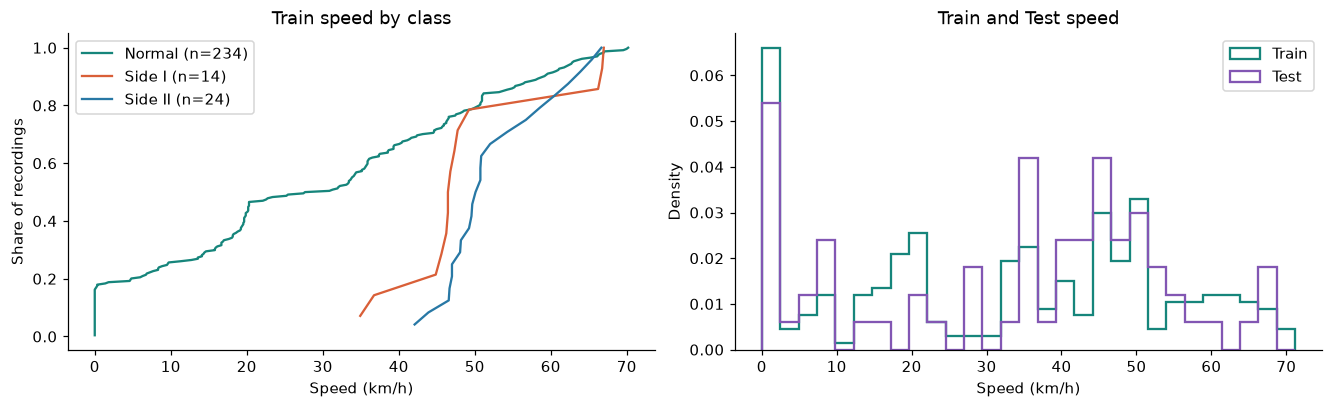

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for label in CLASSES:
    s = np.sort(quality.loc[quality['group'].eq(label), 'speed_kmh'])
    axes[0].plot(s, np.arange(1, len(s) + 1) / len(s), color=COLORS[label], label=f'{label} (n={len(s)})')
axes[0].set(xlabel='Speed (km/h)', ylabel='Share of recordings', title='Train speed by class')
axes[0].legend()
bins = np.linspace(0, quality['speed_kmh'].max() + 1, 30)
for split, color in [('Train', COLORS['Normal']), ('Test', COLORS['Test'])]:
    axes[1].hist(quality.loc[quality['dataset'].eq(split), 'speed_kmh'], bins=bins, density=True,
                 histtype='step', linewidth=1.5, color=color, label=split)
axes[1].set(xlabel='Speed (km/h)', ylabel='Density', title='Train and Test speed')
axes[1].legend()
plt.show()

<blockquote><h3 id="3-7"><b>3.7 Class Counts by Speed Band</b></h3></blockquote>

In the cell below, recordings are counted by speed band and class. The table shows where the classes
overlap in speed, which is where a model must separate them without relying on speed.

In [14]:
quality['speed_band'] = pd.cut(quality['speed_kmh'], [-0.1, 0.5, 20, 40, 60, 80],
                               labels=['stationary', '0.5-20', '20-40', '40-60', '60-80']).astype(str)
band_order = ['stationary', '0.5-20', '20-40', '40-60', '60-80', 'All']
display(pd.crosstab(quality['speed_band'], quality['group'], margins=True).reindex(band_order)[groups + ['All']])

group,Normal,Side I,Side II,Test,All
speed_band,,,,,
stationary,42,0,0,9,51
0.5-20,58,0,0,9,67
20-40,55,2,0,16,73
40-60,58,9,19,30,116
60-80,21,3,5,4,33
All,234,14,24,68,340


<blockquote><h3 id="3-8"><b>3.8 Sample Traces</b></h3></blockquote>

In the cell below, the first 0.1 seconds of the position 1 (Side I) and position 2 (Side II) vibration
channels of car 1 are plotted for one Train recording of each class between 45 and 55 km/h, with each
channel's offset removed.

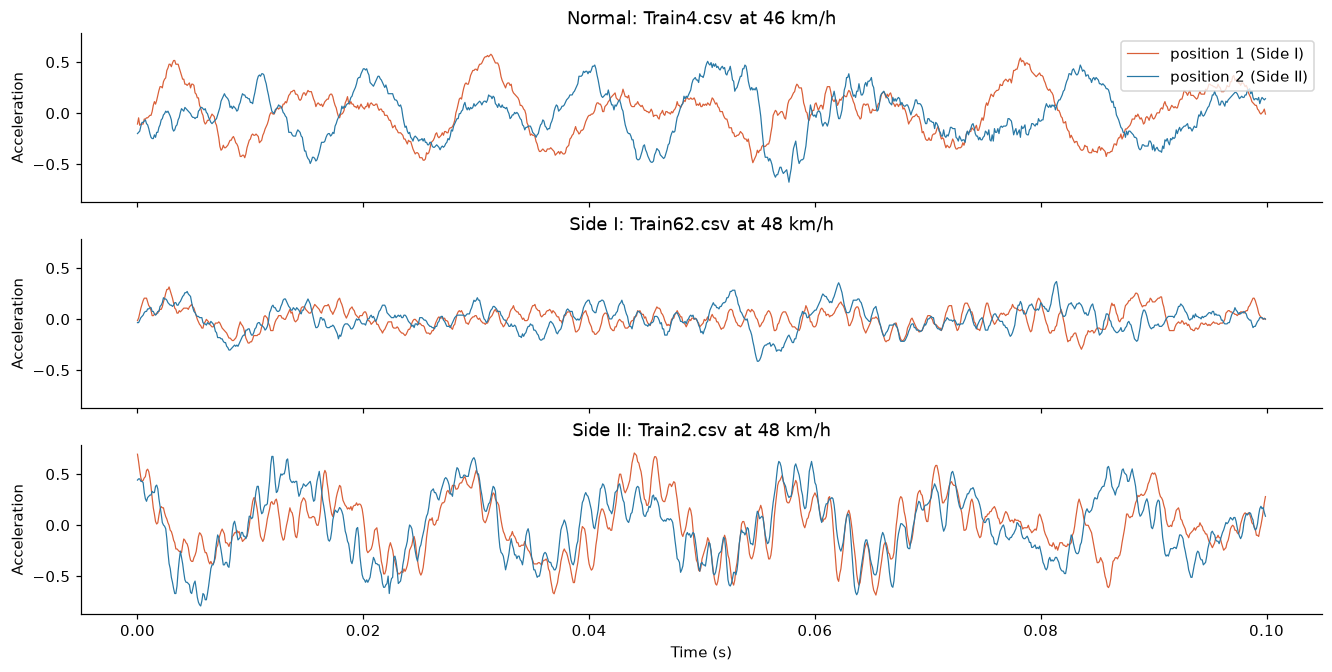

In [15]:
examples = {label: quality[quality['group'].eq(label) & quality['speed_kmh'].between(45, 55)].iloc[0] for label in CLASSES}
t = np.arange(1000) / FS
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True, sharey=True)
for ax, (label, row) in zip(axes, examples.items()):
    frame = read_recording(RAIL_DIR / 'Train' / row['filename'])
    for position, side in [(1, 'Side I'), (2, 'Side II')]:
        trace = frame[f'Vibration of bearing in position {position} of car 1'].to_numpy()
        ax.plot(t, trace[:1000] - trace.mean(), color=COLORS[side], linewidth=0.8, label=f'position {position} ({side})')
    ax.set(title=f"{label}: {row['filename']} at {row['speed_kmh']:.0f} km/h", ylabel='Acceleration')
axes[0].legend(loc='upper right')
axes[-1].set_xlabel('Time (s)')
plt.show()

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Signal Conditioning and Band Definitions</b></h2>
</div>

This section defines how each recording is conditioned and summarised before feature extraction: offset
removal, the Welch spectral estimate, and the frequency and wavelength bands. Only the channel mean is
removed; no filtering is applied, so every later feature is traceable to the raw signal.

<blockquote><h3 id="4-1"><b>4.1 Offset Removal</b></h3></blockquote>

In the cell below, the conditioning function subtracts each channel's mean. The table compares the
median absolute offset of each channel kind with its median standard deviation, which shows why raw
RMS values would mix the sensor offset with the vibration.

In [16]:
def condition(accel):
    """Subtract each channel's mean (its DC offset); no other filtering is applied."""
    return accel - accel.mean(axis=0)


display(channel_stats.groupby('kind').agg(median_abs_offset=('mean', lambda s: s.abs().median()),
                                          median_std=('std', 'median')).assign(
    offset_to_std=lambda t: t['median_abs_offset'] / t['median_std']).round(3))

,median_abs_offset,median_std,offset_to_std
kind,,,
Shock,0.524,1.271,0.412
Vibration,0.049,0.227,0.214


<blockquote><h3 id="4-2"><b>4.2 Spectral Estimation Settings</b></h3></blockquote>

In the cell below, the Welch estimate is defined with 1,024-sample Hann segments and 50% overlap, as in
the exploratory analysis. Its frequency resolution and the number of averaged segments per recording
are reported.

In [17]:
NPERSEG, NOVERLAP = 1024, 512
FREQS = np.fft.rfftfreq(NPERSEG, 1 / FS)
DF = FREQS[1]


def welch_psd(x):
    """Welch power spectral density of each column of `x` (frequencies x channels)."""
    return signal.welch(x, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP, window='hann', detrend='constant', axis=0)[1]


print(f'Resolution {DF:.3f} Hz, {len(FREQS)} bins, {(10_000 - NPERSEG) // (NPERSEG - NOVERLAP) + 1} segments per recording')

Resolution 9.766 Hz, 513 bins, 18 segments per recording


<blockquote><h3 id="4-3"><b>4.3 Frequency and Wavelength Bands</b></h3></blockquote>

Frequency bands follow the exploratory analysis. Corrugation is a periodic rail profile, so it excites
the axle box at the frequency given by train speed divided by the corrugation wavelength. In the cell
below, six octave-wide wavelength bands from 10 to 640 mm are defined, and each is converted to a
frequency range at the recording's speed. A band is defined only when at least two spectral bins fall
inside it, so wavelength features are missing for stationary recordings and for long wavelengths at
low speed. The table gives the number of bins per band at four speeds.

In [18]:
FREQ_BANDS = {'f0_100': (0, 100), 'f100_500': (100, 500), 'f500_1500': (500, 1500), 'f1500_5000': (1500, 5001)}
WAVE_BANDS = {'w10_20mm': (0.01, 0.02), 'w20_40mm': (0.02, 0.04), 'w40_80mm': (0.04, 0.08),
              'w80_160mm': (0.08, 0.16), 'w160_320mm': (0.16, 0.32), 'w320_640mm': (0.32, 0.64)}
MIN_BINS = 2


def wavelength_bins(speed_ms, lo_m, hi_m):
    """Boolean mask of the non-zero frequency bins that correspond to wavelengths in [lo_m, hi_m)."""
    if speed_ms <= 0:
        return np.zeros(len(FREQS), dtype=bool)
    return (FREQS > 0) & (FREQS > speed_ms / hi_m) & (FREQS <= speed_ms / lo_m)


display(pd.DataFrame({f'{kmh} km/h': {name: int(wavelength_bins(kmh / 3.6, *band).sum()) for name, band in WAVE_BANDS.items()}
                      for kmh in [10, 20, 40, 60]}).rename_axis('PSD bins per band'))

,10 km/h,20 km/h,40 km/h,60 km/h
PSD bins per band,,,,
w10_20mm,14,28,57,85
w20_40mm,7,14,28,43
w40_80mm,4,7,14,21
w80_160mm,2,4,7,11
w160_320mm,1,2,4,5
w320_640mm,0,1,2,3


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Feature Extraction</b></h2>
</div>

This section extracts per-channel features in a second pass over the recordings, keeps the spectra,
and aggregates the channels per rail side and as same-axle side contrasts to give one row per recording.

<blockquote><h3 id="5-1"><b>5.1 Channel Feature Function</b></h3></blockquote>

In the cell below, the feature function conditions a recording and computes, for every channel, the RMS,
peak, crest factor, kurtosis and skewness, the spectral centroid, the share of power in each frequency
band, and the base-10 logarithm of the power in each wavelength band. It also returns the spectra.

In [19]:
def channel_features(accel, speed_ms):
    """Per-channel features of one recording (one row per channel) and its spectra."""
    x = condition(accel)
    rms = np.sqrt(np.mean(x ** 2, axis=0))
    peak = np.abs(x).max(axis=0)
    psd = welch_psd(x)
    total = psd.sum(axis=0)
    nan = np.full(x.shape[1], np.nan)
    feats = {'ac_rms': rms, 'peak': peak, 'crest': np.divide(peak, rms, out=nan.copy(), where=rms > 0),
             'kurtosis': stats.kurtosis(x, axis=0), 'skewness': stats.skew(x, axis=0),
             'spectral_centroid': np.divide((FREQS[:, None] * psd).sum(axis=0), total, out=nan.copy(), where=total > 0)}
    for name, (lo, hi) in FREQ_BANDS.items():
        inside = (FREQS >= lo) & (FREQS < hi)
        feats[f'{name}_share'] = np.divide(psd[inside].sum(axis=0), total, out=nan.copy(), where=total > 0)
    for name, band in WAVE_BANDS.items():
        inside = wavelength_bins(speed_ms, *band)
        power = psd[inside].sum(axis=0) * DF if inside.sum() >= MIN_BINS else nan.copy()
        feats[f'{name}_logpow'] = np.log10(np.where(power > 0, power, np.nan))
    return pd.DataFrame(feats), psd

<blockquote><h3 id="5-2"><b>5.2 Extraction Pass</b></h3></blockquote>

In the cell below, every recording is read again, its channel features are computed at its own speed,
and its spectra are stored as 32-bit floats in an array of recordings by channels by frequencies.

In [20]:
speed_ms = dict(zip(quality['filename'], quality['speed_kmh'] / 3.6))
feature_parts, spectra = [], []
for split, name in quality[['dataset', 'filename']].itertuples(index=False):
    accel = read_recording(RAIL_DIR / split / name).to_numpy(dtype=float)[:, 1:]
    feats, psd = channel_features(accel, speed_ms[name])
    feature_parts.append(feats.assign(filename=name, column=channels['column'].to_numpy()))
    spectra.append(psd.T.astype(np.float32))
channel_table = pd.concat(feature_parts, ignore_index=True).merge(channels, on='column')
PSD = np.stack(spectra)
CHANNEL_FEATURES = [c for c in feature_parts[0].columns if c not in ('filename', 'column')]
print('Channel feature rows:', len(channel_table), '| spectra array:', PSD.shape, f'({PSD.nbytes / 1e6:.0f} MB)')

Channel feature rows: 43520 | spectra array: (340, 128, 513) (89 MB)


<blockquote><h3 id="5-3"><b>5.3 Side Aggregation</b></h3></blockquote>

In the cell below, each channel feature is summarised per recording, kind and rail side by its median
over the 32 channels on that side, and the largest RMS on each side is added. Medians keep one faulty
channel from dominating a side.

In [21]:
TAG = {'Side I': 'I', 'Side II': 'II'}
by_side = channel_table.groupby(['filename', 'kind', 'side'])
side_features = by_side[CHANNEL_FEATURES].median().unstack(['kind', 'side'])
side_features.columns = [f'{kind.lower()}_{TAG[side]}_{feat}' for feat, kind, side in side_features.columns]
max_rms = by_side['ac_rms'].max().unstack(['kind', 'side'])
max_rms.columns = [f'{kind.lower()}_{TAG[side]}_max_rms' for kind, side in max_rms.columns]
side_features = side_features.join(max_rms)
print('Side features:', side_features.shape[1])

Side features: 68


<blockquote><h3 id="5-4"><b>5.4 Same-Axle Side Contrasts</b></h3></blockquote>

In the cell below, the Side I channel of each axle is compared with the Side II channel of the same
axle, car and kind: the difference of log RMS, of kurtosis and of each wavelength-band log power. Both
ends of an axle share the same speed and vehicle, so the difference cancels much of what is common to
them. Each recording is summarised by the median difference over its 32 axles and the share of axles
with a positive difference.

In [22]:
keyed = channel_table.assign(log_rms=np.log(channel_table['ac_rms'].where(channel_table['ac_rms'] > 0)))
CONTRASTED = ['log_rms', 'kurtosis'] + [f'{name}_logpow' for name in WAVE_BANDS]
index = ['filename', 'kind', 'car', 'axle']
odd = keyed[keyed['position'] % 2 == 1].set_index(index)[CONTRASTED]
even = keyed[keyed['position'] % 2 == 0].set_index(index)[CONTRASTED]
difference = odd - even  # Side I minus Side II
median = difference.groupby(['filename', 'kind']).median()
positive = (difference > 0).where(difference.notna()).groupby(['filename', 'kind']).mean()
contrast_features = pd.concat({'median': median, 'pos_share': positive}, axis=1).unstack('kind')
contrast_features.columns = [f'{kind.lower()}_contrast_{feat}_{stat}' for stat, feat, kind in contrast_features.columns]
print('Contrast features:', contrast_features.shape[1])

Contrast features: 32


<blockquote><h3 id="5-5"><b>5.5 File-Level Feature Table</b></h3></blockquote>

In the cell below, speed, the side aggregates and the contrasts are joined into one row per recording,
and the features are grouped by type. Missing values are counted per group for moving and stationary
recordings.

In [23]:
features = (quality.set_index('filename')[['dataset', 'label', 'speed_kmh', 'stationary']]
            .join(side_features).join(contrast_features))
FEATURES = [c for c in features.columns if c not in ('dataset', 'label', 'stationary')]
GROUPS = {
    'speed': ['speed_kmh'],
    'amplitude': [c for c in FEATURES if c.endswith(('_ac_rms', '_peak', '_max_rms')) and '_contrast_' not in c],
    'waveform shape': [c for c in FEATURES if c.endswith(('_crest', '_kurtosis', '_skewness')) and '_contrast_' not in c],
    'spectral shape': [c for c in FEATURES if c.endswith(('_centroid', '_share')) and '_contrast_' not in c],
    'wavelength power': [c for c in FEATURES if c.endswith('_logpow')],
    'side contrast': [c for c in FEATURES if '_contrast_' in c],
}
assert sum(map(len, GROUPS.values())) == len(FEATURES)
display(pd.DataFrame({group: {'features': len(cols),
                              'missing (moving)': int(features.loc[~features['stationary'], cols].isna().sum().sum()),
                              'missing (stationary)': int(features.loc[features['stationary'], cols].isna().sum().sum())}
                      for group, cols in GROUPS.items()}).T)
print('Feature table:', features.shape)

,features,missing (moving),missing (stationary)
speed,1,0,0
amplitude,12,0,0
waveform shape,12,0,0
spectral shape,20,0,0
wavelength power,24,760,1128
side contrast,32,760,1128


Feature table: (340, 104)


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Train and Test Comparability</b></h2>
</div>

This section checks whether the Test recordings fall inside the feature ranges seen in Train, by
feature group, and how wavelength-feature coverage depends on speed.

<blockquote><h3 id="6-1"><b>6.1 Feature Range Comparison</b></h3></blockquote>

In the cell below, the number of Test recordings outside the Train range is counted for every feature
and summarised by feature group. The ten features with the most out-of-range Test recordings are
listed.

In [24]:
train_part, test_part = features[features['dataset'].eq('Train')], features[features['dataset'].eq('Test')]
outside = pd.Series({f: int(((test_part[f] < train_part[f].min()) | (test_part[f] > train_part[f].max())).sum())
                     for f in FEATURES})
display(pd.DataFrame({group: {'features': len(cols), 'features with Test outside Train range': int((outside[cols] > 0).sum()),
                              'out-of-range Test values': int(outside[cols].sum())} for group, cols in GROUPS.items()}).T)
display(outside.sort_values(ascending=False).head(10).rename('Test recordings outside Train range').to_frame())

,features,features with Test outside Train range,out-of-range Test values
speed,1,0,0
amplitude,12,4,4
waveform shape,12,7,10
spectral shape,20,7,12
wavelength power,24,6,9
side contrast,32,8,10


,Test recordings outside Train range
vibration_II_f100_500_share,4
shock_I_w20_40mm_logpow,3
shock_I_kurtosis,3
vibration_contrast_w320_640mm_logpow_median,2
vibration_I_f100_500_share,2
shock_I_f1500_5000_share,2
vibration_II_skewness,2
vibration_II_w80_160mm_logpow,2
shock_contrast_w320_640mm_logpow_pos_share,2
shock_II_w20_40mm_logpow,1


<blockquote><h3 id="6-2"><b>6.2 Wavelength Coverage by Speed</b></h3></blockquote>

In the cell below, the percentage of recordings with a defined value is shown for each wavelength band
of the Side I vibration channels, by speed band.

In [25]:
wave_columns = [f'vibration_I_{name}_logpow' for name in WAVE_BANDS]
coverage = (features[wave_columns].notna().groupby(quality.set_index('filename')['speed_band']).mean() * 100).round(0)
display(coverage.rename(columns=lambda c: c.removeprefix('vibration_I_').removesuffix('_logpow')).T)

speed_band,0.5-20,20-40,40-60,60-80,stationary
w10_20mm,100.0,100.0,100.0,100.0,0.0
w20_40mm,97.0,100.0,100.0,100.0,0.0
w40_80mm,96.0,100.0,100.0,100.0,0.0
w80_160mm,73.0,100.0,100.0,100.0,0.0
w160_320mm,36.0,100.0,100.0,100.0,0.0
w320_640mm,0.0,55.0,100.0,100.0,0.0


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Validation Folds</b></h2>
</div>

This section assigns fixed validation folds to the Train recordings so that every model is compared on
the same splits, with duplicated recordings kept together.

<blockquote><h3 id="7-1"><b>7.1 Grouped Stratified Folds</b></h3></blockquote>

In the cell below, the Train recordings are divided into four folds stratified by class with the fixed
seed, grouping recordings by their acceleration fingerprint so that duplicates share a fold. Every fold
must contain all three classes, and the median speed per fold and class is shown.

In [26]:
train_index = features.index[features['dataset'].eq('Train')]
fingerprints = quality.set_index('filename').loc[train_index, 'accel_sha256']
features['fold'] = pd.Series(pd.NA, index=features.index, dtype='Int64')
splitter = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
for fold, (_, valid) in enumerate(splitter.split(np.zeros(len(train_index)), features.loc[train_index, 'label'], groups=fingerprints)):
    features.loc[train_index[valid], 'fold'] = fold
assert features.loc[train_index].groupby(fingerprints)['fold'].nunique().eq(1).all()
fold_counts = pd.crosstab(features.loc[train_index, 'fold'], features.loc[train_index, 'label'], margins=True)
assert fold_counts.loc[range(4), CLASSES].gt(0).all().all(), 'Every fold needs all three classes.'
display(fold_counts)
display(features.loc[train_index].pivot_table(index='fold', columns='label', values='speed_kmh', aggfunc='median').round(1))

label,Normal,Side I,Side II,All
fold,,,,
0,58,4,6,68
1,59,3,6,68
2,59,3,6,68
3,58,4,6,68
All,234,14,24,272


label,Normal,Side I,Side II
fold,,,
0,33.2,66.5,51.4
1,36.5,45.6,48.9
2,18.1,46.5,51.7
3,33.8,46.9,50.4


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Export</b></h2>
</div>

This section writes the prepared tables to Parquet and the spectra to a NumPy archive, records a
manifest of settings and sources, and verifies that every output reads back identically.

<blockquote><h3 id="8-1"><b>8.1 Output Tables</b></h3></blockquote>

In the cell below, three tables and one array archive are written: one row per recording with quality,
speed, fingerprints, label and fold; one row per recording and channel with the channel features and
health statistics; one
row per recording with the aggregated features; and the spectra with their frequency, recording and
channel axes. Text columns are stored with the pandas string type.

In [27]:
def for_parquet(frame):
    """Copy of `frame` with a fresh index and object columns converted to the pandas string dtype."""
    out = frame.reset_index(drop=True).copy()
    for column in out.columns[out.dtypes.eq(object)]:
        out[column] = out[column].astype('string')
    return out


quality['fold'] = quality['filename'].map(features['fold']).astype('Int64')
outputs = {
    'rail_files.parquet': for_parquet(quality.drop(columns='group')),
    'rail_channel_features.parquet': for_parquet(channel_table.merge(
        channel_stats[['filename', 'column', 'mean', 'extreme_share', 'levels', 'step']].rename(columns={'mean': 'offset'}),
        on=['filename', 'column'], validate='one_to_one')),
    'rail_features.parquet': for_parquet(features.reset_index()),
}
for name, frame in outputs.items():
    frame.to_parquet(OUT_DIR / name, index=False)
np.savez(OUT_DIR / 'rail_psd.npz', psd=PSD, frequencies=FREQS, filenames=quality['filename'].to_numpy(dtype=str),
         channels=channels['column'].to_numpy(dtype=str))
sizes = {name: (len(frame), frame.shape[1]) for name, frame in outputs.items()} | {'rail_psd.npz': PSD.shape}
display(pd.DataFrame([{'file': name, 'shape': shape, 'size_MB': round((OUT_DIR / name).stat().st_size / 1e6, 2)}
                      for name, shape in sizes.items()]))

,file,shape,size_MB
0,rail_files.parquet,"(340, 20)",0.07
1,rail_channel_features.parquet,"(43520, 27)",6.61
2,rail_features.parquet,"(340, 106)",0.32
3,rail_psd.npz,"(340, 128, 513)",89.35


<blockquote><h3 id="8-2"><b>8.2 Manifest</b></h3></blockquote>

In the cell below, a JSON manifest records the settings, the feature groups and the size of each
output. Source fingerprints are stored per recording in `rail_files.parquet`.

In [28]:
manifest = {
    'subsystem': 'Rail_Corrugation',
    'settings': {'seed': SEED, 'fs': FS, 'teeth': TEETH, 'wheel_diameter_m': WHEEL_DIAMETER_M,
                 'speed_rule': 'rising pulse edges per second / teeth * pi * diameter',
                 'conditioning': 'channel mean removed; no filtering', 'welch': {'nperseg': NPERSEG, 'noverlap': NOVERLAP, 'window': 'hann'},
                 'frequency_bands_hz': FREQ_BANDS, 'wavelength_bands_m': WAVE_BANDS, 'min_bins': MIN_BINS,
                 'axle_pairs': '(1,2), (3,4), (5,6), (7,8)', 'folds': 'StratifiedGroupKFold(4) grouped by acceleration fingerprint'},
    'feature_groups': GROUPS,
    'outputs': {name: list(shape) for name, shape in sizes.items()},
}
(OUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest['settings'], indent=2))

{
  "seed": 2026,
  "fs": 10000,
  "teeth": 90,
  "wheel_diameter_m": 0.85,
  "speed_rule": "rising pulse edges per second / teeth * pi * diameter",
  "conditioning": "channel mean removed; no filtering",
  "welch": {
    "nperseg": 1024,
    "noverlap": 512,
    "window": "hann"
  },
  "frequency_bands_hz": {
    "f0_100": [
      0,
      100
    ],
    "f100_500": [
      100,
      500
    ],
    "f500_1500": [
      500,
      1500
    ],
    "f1500_5000": [
      1500,
      5001
    ]
  },
  "wavelength_bands_m": {
    "w10_20mm": [
      0.01,
      0.02
    ],
    "w20_40mm": [
      0.02,
      0.04
    ],
    "w40_80mm": [
      0.04,
      0.08
    ],
    "w80_160mm": [
      0.08,
      0.16
    ],
    "w160_320mm": [
      0.16,
      0.32
    ],
    "w320_640mm": [
      0.32,
      0.64
    ]
  },
  "min_bins": 2,
  "axle_pairs": "(1,2), (3,4), (5,6), (7,8)",
  "folds": "StratifiedGroupKFold(4) grouped by acceleration fingerprint"
}


<blockquote><h3 id="8-3"><b>8.3 Export Verification</b></h3></blockquote>

In the cell below, each Parquet file is read back and compared with the table in memory, and the spectra
archive is reloaded and compared array by array.

In [29]:
for name, frame in outputs.items():
    pd.testing.assert_frame_equal(pd.read_parquet(OUT_DIR / name), frame)
with np.load(OUT_DIR / 'rail_psd.npz') as archive:
    assert np.array_equal(archive['psd'], PSD) and np.array_equal(archive['frequencies'], FREQS)
    assert list(archive['filenames']) == list(quality['filename']) and list(archive['channels']) == list(channels['column'])
print('All outputs read back identically.')

All outputs read back identically.


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Conclusions</b></h2>
</div>

This section summarises the prepared outputs, the data-quality findings, and their implications for
model training. All statements refer to the executed results above.

<blockquote><h3 id="9-1"><b>9.1 Prepared Outputs</b></h3></blockquote>

- `rail_files.parquet` holds one row for each of the 340 recordings with its audit results, speed,
  stationary flag, speed band, fingerprints, label and fold.
- `rail_channel_features.parquet` holds 43,520 recording-and-channel rows with 16 channel features and
  the channel-health statistics (offset, share at extremes, distinct levels and quantisation step).
- `rail_features.parquet` holds 101 features per recording: speed, 68 side aggregates (12 amplitude,
  12 waveform-shape, 20 spectral-shape and 24 wavelength-power features) and 32 same-axle side
  contrasts, with labels and folds. `rail_psd.npz` holds the Welch spectra as a 340 by 128 by 513
  array of 32-bit floats (89 MB) with its recording, channel and frequency axes.
- Every output reads back identically, and `manifest.json` records the acquisition constants, the
  conditioning, the band definitions, the axle pairing and the fold scheme.

<blockquote><h3 id="9-2"><b>9.2 Data Quality Findings</b></h3></blockquote>

- The 272 Train and 68 Test recordings are numbered without gaps and share one 129-column header. Every
  recording has 10,000 numeric rows, with no missing or infinite values, no pulse values other than 0
  and 1, and no constant channel.
- The labels cover every Train recording exactly once: 234 `Normal` (86.0%), 14 `Side I` (5.1%) and
  24 `Side II` (8.8%).
- Two pairs of Train recordings are identical (`Train107.csv` and `Train115.csv`, `Train165.csv` and
  `Train187.csv`), and all four are `Normal`. No Test recording repeats a Train recording.
- Every channel is quantised in steps of 0.0122. Vibration channels have a median of 150 distinct
  levels, and 1,179 vibration channel recordings have fewer than 20 levels, 920 of them in stationary
  recordings. No shock channel recording and 115 vibration channel recordings have more than 1% of
  samples at their extremes.
- Offsets are material: the median absolute offset is 41% of the median standard deviation for shock
  channels and 21% for vibration channels, so the offset is removed before any RMS or spectrum.
- The rising-edge and both-edge speed estimates agree within 0.053 km/h. Forty-seven recordings have
  no pulse edge (38 `Normal` Train and 9 Test recordings).

<blockquote><h3 id="9-3"><b>9.3 Implications for Modelling</b></h3></blockquote>

- Speed is confounded with the class: `Side I` recordings run at 34.9 to 67.0 km/h and `Side II` at
  42.1 to 66.7 km/h, whereas `Normal` recordings span 0 to 70.2 km/h. All 100 Train recordings below
  20 km/h are `Normal`, and 18 Test recordings fall in that range.
- The classes overlap between 40 and 60 km/h (58 `Normal`, 9 `Side I` and 19 `Side II` recordings),
  which is where a model has to separate them by the signal rather than by speed.
- Wavelength features are undefined for stationary recordings and for long wavelengths at low speed:
  the 320 to 640 mm band is defined for none of the recordings between 0.5 and 20 km/h and for 55% of
  those between 20 and 40 km/h, while every band is defined above 40 km/h.
- Test recordings stay close to the Train ranges: 32 of the 101 features have any Test value outside
  the Train range, and no feature has more than 4 of the 68 Test recordings outside it.
- Each of the four folds holds 68 recordings with 3 or 4 `Side I` and 6 `Side II` recordings, and
  the duplicate pairs share a fold. With so few corrugated recordings per fold, per-class F1 will vary
  noticeably between folds.
- The same-axle contrasts rest on the assumed pairing of positions (1, 2), (3, 4), (5, 6) and (7, 8);
  the side aggregates do not depend on it.